In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

%matplotlib inline

In [4]:
import os

path = r"C:\Users\52444\.cache\kagglehub\datasets\asaniczka\uk-optimal-product-price-prediction\versions\3"

os.listdir(path)


['amz_uk_price_prediction_dataset.csv']

In [5]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\52444\.cache\kagglehub\datasets\asaniczka\uk-optimal-product-price-prediction\versions\3\amz_uk_price_prediction_dataset.csv"
)


In [6]:
df.head()
df.shape
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2443651 entries, 0 to 2443650
Data columns (total 9 columns):
 #   Column             Dtype  
---  ------             -----  
 0   uid                int64  
 1   asin               object 
 2   title              object 
 3   stars              float64
 4   reviews            int64  
 5   price              float64
 6   isBestSeller       bool   
 7   boughtInLastMonth  int64  
 8   category           object 
dtypes: bool(1), float64(2), int64(3), object(3)
memory usage: 151.5+ MB


In [7]:
#TABLAS DE FRECUENCIA
freq_category = (
    df["category"]
    .value_counts()
    .reset_index()
)

freq_category.columns = ["category", "frequency"]
freq_category


,category,frequency
0,Sports & Outdoors,836265
1,Beauty,19312
2,"Handmade Clothing, Shoes & Accessories",19229
3,Bath & Body,19092
4,Birthday Gifts,18978
...,...,...
291,Motorbike Chassis,107
292,Alexa Built-In Devices,107
293,Plugs,107
294,Smart Home Security & Lighting,104


In [9]:
#TOP 5 CATEGORIAS 
top_5_categories = freq_category.head(5)
top_5_categories


,category,frequency
0,Sports & Outdoors,836265
1,Beauty,19312
2,"Handmade Clothing, Shoes & Accessories",19229
3,Bath & Body,19092
4,Birthday Gifts,18978


In [ ]:
#VISUALIZACION 
#BAR CHART


category_counts = (
    df["category"]
    .value_counts()
    .head(10)
    .reset_index()
)

category_counts.columns = ["category", "count"]

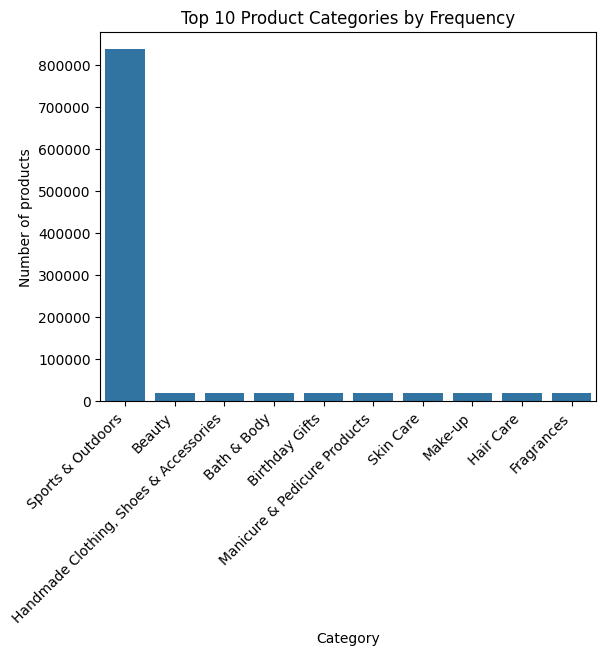

In [13]:
plt.figure()
sns.barplot(
    data=category_counts,
    x="category",
    y="count"
)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Category")
plt.ylabel("Number of products")
plt.title("Top 10 Product Categories by Frequency")
plt.show()


In [14]:
#PIE CHART
top_categories = df["category"].value_counts().head(5)

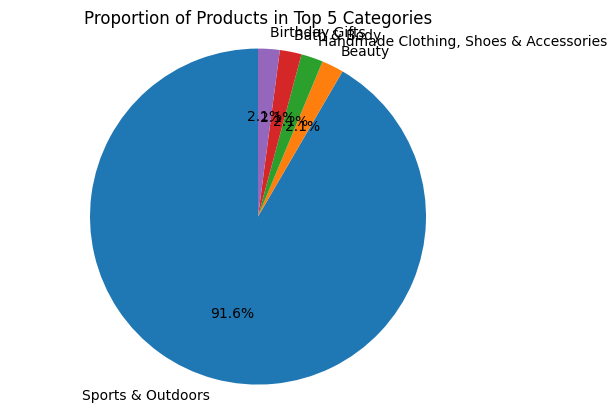

In [15]:
plt.figure()
plt.pie(
    top_categories.values,
    labels=top_categories.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Proportion of Products in Top 5 Categories")
plt.axis("equal")  # Hace el círculo perfecto
plt.show()


In [16]:
#PART 2
#MEAN, MEDIAN, MODE ORICE

mean_price = df["price"].mean()
median_price = df["price"].median()
mode_price = df["price"].mode()[0]

mean_price, median_price, mode_price


(np.float64(89.24380943923661), np.float64(19.09), np.float64(9.99))

In [19]:
#VARIANZA, DESVIACIONESTANDAR, RANGO E INTERCUARTIL 

# Medidas de dispersión
price_variance = df["price"].var()
price_std = df["price"].std()
price_range = df["price"].max() - df["price"].min()

# Rango intercuartílico 
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
price_iqr = Q3 - Q1

price_variance, price_std, price_range, price_iqr


(np.float64(119445.48532254901),
 np.float64(345.60886175349873),
 np.float64(100000.0),
 np.float64(36.0))

Exsite un rango muy amplio en los precios tanto el mas barato como el mas caro, sin embargo por el rango intercuaalitico podemos ver que la mayyoria de los productos tienen precios similares, tambien hay una distribucion muy dispersa con outliers de altos precios 

<Axes: xlabel='price', ylabel='Count'>

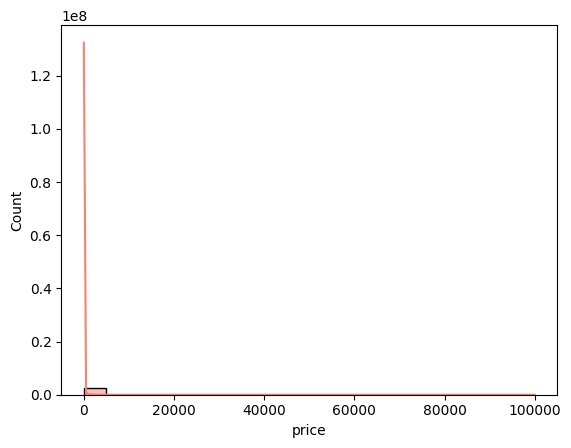

In [20]:
#HISTOGRAMA

sns.histplot(df['price'], kde=True, bins=20, color="salmon")

In [ ]:
#PART 3
#PREGUNTAS EMPRESARIALES 


CALIFICACIONES DE LOS CLIENTES
Generalmente son altas con puntuaciones o ratings entre 4 y 5 estrellas, su media y mediana tambien estan por encima de 4. Los lcientes califican mejor si tienen buena experienciay si exiten malas calificaciones pero son minoria

In [22]:
df.columns

Index(['uid', 'asin', 'title', 'stars', 'reviews', 'price', 'isBestSeller',
       'boughtInLastMonth', 'category'],
      dtype='object')

In [23]:
#RATING: MEDIA, MEDIANA Y MODA
mean_rating = df["stars"].mean()
median_rating = df["stars"].median()
mode_rating = df["stars"].mode()[0]

mean_rating, median_rating, mode_rating


(np.float64(2.152836472966066), np.float64(0.0), np.float64(0.0))

La mayoria no tienen valoracion, puede ser a que son productos nuevos o sin calificacion 

In [24]:
#VARIANZA, DESVIACION ESTANDAR E INDICE INTERCUARTIL 

rated_products = df[df["stars"] > 0]

variance_rated = rated_products["stars"].var()
std_rated = rated_products["stars"].std()
iqr_rated = (
    rated_products["stars"].quantile(0.75)
    - rated_products["stars"].quantile(0.25)
)

variance_rated, std_rated, iqr_rated


(np.float64(0.3083433752387284),
 np.float64(0.5552867504620729),
 np.float64(0.5))

In [25]:
skewness_stars = df["stars"].skew()
kurtosis_stars = df["stars"].kurt()

skewness_stars, kurtosis_stars


(np.float64(0.08120735761080881), np.float64(-1.9260061280432994))

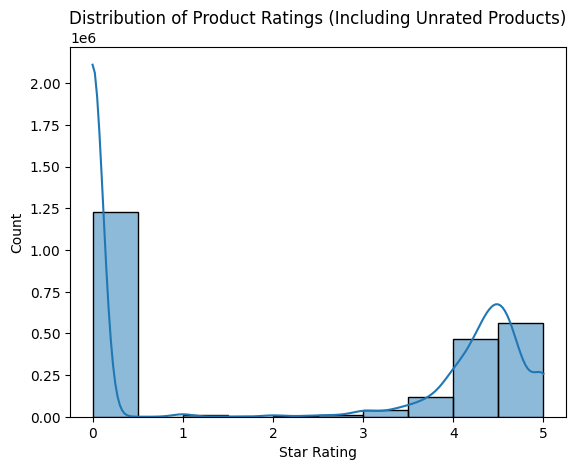

In [ ]:
#HISTOGRAMA
plt.figure()
sns.histplot(df["stars"], bins=10, kde=True)
plt.xlabel("Star Rating")
plt.ylabel("Count")
plt.title("Distribution of Product Ratings (Including Unrated Products)")
plt.show()

# INFORME

El análisis nos muestra que una gran cantidad de productos no presentan calificacion, esto puede ser a que no han recibido reseñas, esto afecta  a las medidas de la media y la moda
Si tomamos en cuenta unicamente lsoproductos que han sido valoraods, nos encontramos que cambia por completo y que las calificaciones fluctian entre 4 y 5 estrellas.